## 1. Spectral analysis

Inspect singular-value spectra of the pretrained ResNet-20 middle convolutional layer and final classifier.


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to ~/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to ~/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100.0%


----- Middle layer (Conv) -----
Layer name           : layer2.1.conv1
Original weight shape: (32, 32, 3, 3)
Reshaped 2D shape    : (32, 288)
Max rank             : 32
k for 95% energy     : 28
Percent of max rank  : 87.50%

----- Final layer (Linear) -----
Layer name           : fc
Original weight shape: (10, 64)
Reshaped 2D shape    : (10, 64)
Max rank             : 10
k for 95% energy     : 9
Percent of max rank  : 90.00%


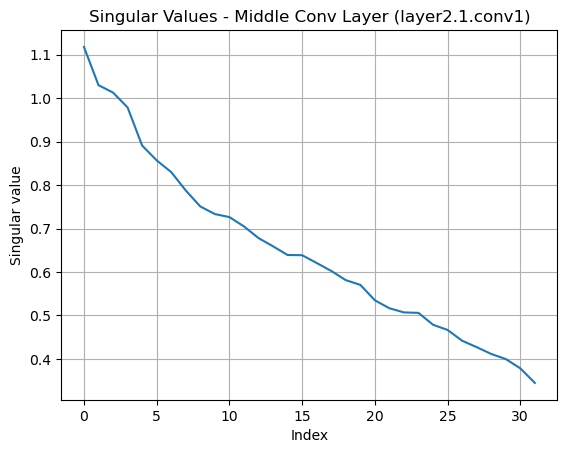

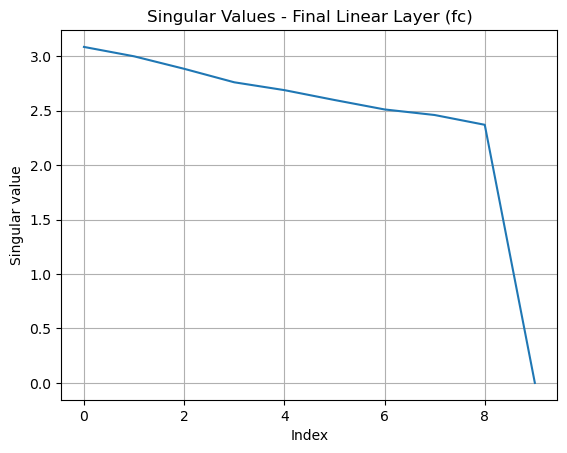

In [5]:
# =========================
# Part 1: Spectral analysis of pretrained CIFAR-10 model weights
# Steps:
# 1) Load a CIFAR-10 pretrained model
# 2) Extract weights from one middle Conv layer + final Linear layer
# 3) Plot singular values and compute k for 95% energy
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------- Step 1.1: Load CIFAR-10 pretrained model ----------
# This repo provides pretrained models for CIFAR-10 via torch.hub
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
model.eval()

# ---------- Helper functions ----------
def weight_to_2d(W: np.ndarray) -> np.ndarray:
    """
    Convert weight tensor to a 2D matrix for SVD.
    - Conv: (out_ch, in_ch, kH, kW) -> (out_ch, in_ch*kH*kW)
    - Linear: already 2D
    """
    if W.ndim == 4:
        out_ch, in_ch, kH, kW = W.shape
        return W.reshape(out_ch, in_ch * kH * kW)
    elif W.ndim == 2:
        return W
    else:
        raise ValueError(f"Unsupported weight shape: {W.shape}")

def sv_spectrum_and_k95(W2d: np.ndarray):
    """
    Compute singular values and k that preserves 95% energy.
    Energy is sum of squared singular values.
    """
    s = np.linalg.svd(W2d, compute_uv=False)  # sorted desc
    energy = s**2
    ratio = np.cumsum(energy) / np.sum(energy)
    k95 = int(np.searchsorted(ratio, 0.95) + 1)
    return s, ratio, k95

def plot_singular_values(s, title):
    plt.figure()
    plt.plot(s)
    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("Singular value")
    plt.grid(True)
    plt.show()

# ---------- Step 1.2: Pick a middle Conv layer and the final Linear layer ----------
# We do it robustly by searching modules:
conv_names = []
linear_names = []

for name, m in model.named_modules():
    if isinstance(m, torch.nn.Conv2d):
        conv_names.append(name)
    if isinstance(m, torch.nn.Linear):
        linear_names.append(name)

if len(conv_names) == 0 or len(linear_names) == 0:
    raise RuntimeError("Could not find Conv2d or Linear layers in the model.")

# Choose a "middle" conv layer (roughly in the middle of the list)
mid_conv_name = conv_names[len(conv_names) // 2]
final_linear_name = linear_names[-1]

mid_conv_layer = dict(model.named_modules())[mid_conv_name]
final_linear_layer = dict(model.named_modules())[final_linear_name]

W_mid = mid_conv_layer.weight.detach().cpu().numpy()
W_fc = final_linear_layer.weight.detach().cpu().numpy()

# ---------- Step 1.3: SVD spectrum + 95% energy ----------
W_mid_2d = weight_to_2d(W_mid)
W_fc_2d = weight_to_2d(W_fc)

s_mid, ratio_mid, k95_mid = sv_spectrum_and_k95(W_mid_2d)
s_fc, ratio_fc, k95_fc = sv_spectrum_and_k95(W_fc_2d)

print("----- Middle layer (Conv) -----")
print(f"Layer name           : {mid_conv_name}")
print(f"Original weight shape: {W_mid.shape}")
print(f"Reshaped 2D shape    : {W_mid_2d.shape}")
print(f"Max rank             : {min(W_mid_2d.shape)}")
print(f"k for 95% energy     : {k95_mid}")
print(f"Percent of max rank  : {100 * k95_mid / min(W_mid_2d.shape):.2f}%")

print("\n----- Final layer (Linear) -----")
print(f"Layer name           : {final_linear_name}")
print(f"Original weight shape: {W_fc.shape}")
print(f"Reshaped 2D shape    : {W_fc_2d.shape}")
print(f"Max rank             : {min(W_fc_2d.shape)}")
print(f"k for 95% energy     : {k95_fc}")
print(f"Percent of max rank  : {100 * k95_fc / min(W_fc_2d.shape):.2f}%")

# Plot singular value curves
plot_singular_values(s_mid, f"Singular Values - Middle Conv Layer ({mid_conv_name})")
plot_singular_values(s_fc,  f"Singular Values - Final Linear Layer ({final_linear_name})")


## 2. SVD compression and baseline evaluation

Replace the final classifier with two low-rank linear layers, then compare parameters and accuracy on CIFAR-10.


In [6]:
# =========================
# Part 2: Practical low-rank compression on CIFAR-10 pretrained model
# Tasks:
# 1) Write a function to replace a Linear layer with two consecutive Linear layers via rank-k SVD
# 2) Test the model in 3 modes: baseline, 50% compression, 80% compression
# 3) Report initial accuracy on CIFAR-10 test set
# 4) Provide a parameter comparison table
# =========================

import copy
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ---------- Data loader (CIFAR-10) ----------
def get_cifar10_test_loader(batch_size=256, num_workers=2):
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])
    test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
    return DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# ---------- Metrics ----------
@torch.no_grad()
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

def count_params(module):
    return sum(p.numel() for p in module.parameters())

# ---------- Choose k to match a target parameter reduction for the Linear layer ----------
def choose_k_for_linear_param_reduction(out_features, in_features, reduction_ratio):
    """
    reduction_ratio = 0.50 -> reduce 50% (keep 50%)
    reduction_ratio = 0.80 -> reduce 80% (keep 20%)

    Original (weights only): m*n
    Factorized (weights only): k*(m+n)

    Choose largest k such that k*(m+n) <= keep_ratio*(m*n)
    """
    m, n = out_features, in_features
    keep_ratio = 1.0 - reduction_ratio
    k = int((keep_ratio * m * n) / (m + n))
    k = max(1, min(k, min(m, n)))
    return k

# ---------- Core: Linear -> (Linear(in->k) + Linear(k->out)) from SVD ----------
def compress_linear_svd(linear_layer, k):
    """
    Given nn.Linear with weight W (out, in), approximate:
      W ≈ U_k diag(S_k) V_k^T

    Implement as:
      first : Linear(in -> k),  weight = V_k^T, bias=False
      second: Linear(k -> out), weight = U_k diag(S_k), bias=True (keep original bias)
    """
    assert isinstance(linear_layer, nn.Linear), "This function expects nn.Linear"

    W = linear_layer.weight.data
    b = linear_layer.bias.data if linear_layer.bias is not None else None

    # Compact SVD
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    k = min(k, S.numel())

    U_k = U[:, :k]       # (out, k)
    S_k = S[:k]          # (k,)
    Vh_k = Vh[:k, :]     # (k, in)

    first = nn.Linear(linear_layer.in_features, k, bias=False)
    second = nn.Linear(k, linear_layer.out_features, bias=True)

    first.weight.data = Vh_k
    second.weight.data = U_k * S_k.unsqueeze(0)

    if b is not None:
        second.bias.data = b.clone()
    else:
        second.bias.data.zero_()

    return nn.Sequential(first, second)

# ---------- Main experiment ----------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    test_loader = get_cifar10_test_loader()

    # Load CIFAR-10 pretrained model (ResNet20)
    # Note: requires internet the first time, then it uses cache.
    model_base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    model_base.eval()

    # Make compressed copies
    model_50 = copy.deepcopy(model_base)
    model_80 = copy.deepcopy(model_base)

    # Compress only the final Linear layer (fc)
    assert isinstance(model_base.fc, nn.Linear), "Expected model.fc to be nn.Linear"

    m = model_base.fc.out_features
    n = model_base.fc.in_features

    k50 = choose_k_for_linear_param_reduction(m, n, reduction_ratio=0.50)
    k80 = choose_k_for_linear_param_reduction(m, n, reduction_ratio=0.80)

    model_50.fc = compress_linear_svd(model_50.fc, k50)
    model_80.fc = compress_linear_svd(model_80.fc, k80)

    # Move to device
    model_base = model_base.to(device)
    model_50 = model_50.to(device)
    model_80 = model_80.to(device)

    # Accuracy (initial)
    acc_base = evaluate_accuracy(model_base, test_loader, device)
    acc_50 = evaluate_accuracy(model_50, test_loader, device)
    acc_80 = evaluate_accuracy(model_80, test_loader, device)

    # Parameter counts: total model + fc only
    total_base = count_params(model_base)
    total_50 = count_params(model_50)
    total_80 = count_params(model_80)

    fc_base = count_params(model_base.fc)
    fc_50 = count_params(model_50.fc)
    fc_80 = count_params(model_80.fc)

    # Print results
    print("===== Part 2 Results (CIFAR-10 pretrained / Initial) =====")
    print(f"Baseline accuracy: {acc_base:.2f}%")
    print(f"50% compression (fc k={k50}) accuracy: {acc_50:.2f}%")
    print(f"80% compression (fc k={k80}) accuracy: {acc_80:.2f}%")

    print("\n===== Parameter Comparison Table =====")
    print("Model Variant | Total Params | FC Params | FC Reduction")
    print("-"*58)

    def fc_reduction_str(new_fc, old_fc):
        red = 100.0 * (1.0 - (new_fc / old_fc))
        return f"{red:.2f}%"

    print(f"Baseline     | {total_base:,} | {fc_base:,} | 0.00%")
    print(f"50% (k={k50}) | {total_50:,} | {fc_50:,} | {fc_reduction_str(fc_50, fc_base)}")
    print(f"80% (k={k80}) | {total_80:,} | {fc_80:,} | {fc_reduction_str(fc_80, fc_base)}")

    print("\n----- FC Layer Details -----")
    print(f"Original fc shape: (out={m}, in={n})")
    print(f"Original fc params (incl. bias): {fc_base:,}")
    print(f"50% target -> chosen k={k50}, new fc params: {fc_50:,}")
    print(f"80% target -> chosen k={k80}, new fc params: {fc_80:,}")

if __name__ == "__main__":
    main()


Files already downloaded and verified


Using cache found in ~/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


===== Part 2 Results (CIFAR-10 pretrained / Initial) =====
Baseline accuracy: 92.12%
50% compression (fc k=4) accuracy: 76.90%
80% compression (fc k=1) accuracy: 19.81%

===== Parameter Comparison Table =====
Model Variant | Total Params | FC Params | FC Reduction
----------------------------------------------------------
Baseline     | 272,474 | 650 | 0.00%
50% (k=4) | 272,130 | 306 | 52.92%
80% (k=1) | 271,908 | 84 | 87.08%

----- FC Layer Details -----
Original fc shape: (out=10, in=64)
Original fc params (incl. bias): 650
50% target -> chosen k=4, new fc params: 306
80% target -> chosen k=1, new fc params: 84


## 3. Fine-tuning and CPU timing

Fine-tune the classifier for three epochs, assess test accuracy, and benchmark CPU inference time per batch.


Files already downloaded and verified
Files already downloaded and verified


Using cache found in ~/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


===== Before fine-tuning =====
Baseline: 92.12%
Compressed (k=4, actual 52.92%): 76.90%
Compressed (k=1, actual 87.08%): 19.81%

Epoch 1/3
Baseline: loss=0.0128, acc=92.44%
Compressed (k=4): loss=0.0877, acc=90.54%
Compressed (k=1): loss=1.3997, acc=41.84%

Epoch 2/3
Baseline: loss=0.0117, acc=92.42%
Compressed (k=4): loss=0.0505, acc=90.38%
Compressed (k=1): loss=1.2516, acc=42.88%

Epoch 3/3
Baseline: loss=0.0104, acc=92.31%
Compressed (k=4): loss=0.0478, acc=90.61%
Compressed (k=1): loss=1.2126, acc=42.73%

===== CPU inference latency (ms per batch) =====
Baseline: 297.38 ± 49.31 ms
Compressed (k=4): 300.73 ± 53.67 ms
Compressed (k=1): 312.29 ± 55.95 ms


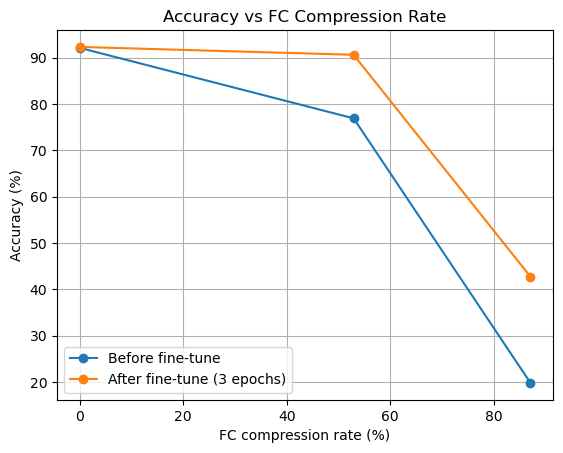

In [8]:
# =========================
# Part 3: Accuracy recovery + CPU speed evaluation (CIFAR-10 pretrained ResNet20)
# Tasks:
# 1) Fine-tune compressed models for at least 3 epochs
# 2) Measure and compare CPU inference speed
# 3) Plot "Accuracy vs Compression Rate"
# Notes:
# - We use CIFAR-10 train/test
# - We fine-tune ONLY the final classifier (fc) to keep it simple and fast
# - Compression rate refers to the FC layer compression (actual % reduction)
# =========================

import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ---------- Data loaders ----------
def get_cifar10_loaders(batch_size=256, num_workers=2):
    # CIFAR-10 normalization (common for CIFAR models)
    tfm_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])

    train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm_train)
    test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm_test)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

# ---------- Evaluation ----------
@torch.no_grad()
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

# ---------- Compression helpers ----------
def count_params(module):
    return sum(p.numel() for p in module.parameters())

def choose_k_for_linear_param_reduction(out_features, in_features, reduction_ratio):
    # reduction_ratio: 0.50 -> reduce 50% (keep 50%), 0.80 -> reduce 80% (keep 20%)
    m, n = out_features, in_features
    keep_ratio = 1.0 - reduction_ratio
    k = int((keep_ratio * m * n) / (m + n))
    k = max(1, min(k, min(m, n)))
    return k

def compress_linear_svd(linear_layer, k):
    # Replace nn.Linear by two nn.Linear layers using rank-k SVD
    W = linear_layer.weight.data
    b = linear_layer.bias.data if linear_layer.bias is not None else None

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    k = min(k, S.numel())

    U_k = U[:, :k]
    S_k = S[:k]
    Vh_k = Vh[:k, :]

    first = nn.Linear(linear_layer.in_features, k, bias=False)
    second = nn.Linear(k, linear_layer.out_features, bias=True)

    first.weight.data = Vh_k
    second.weight.data = U_k * S_k.unsqueeze(0)

    if b is not None:
        second.bias.data = b.clone()
    else:
        second.bias.data.zero_()

    return nn.Sequential(first, second)

# ---------- CPU inference timing (FIXED: no StopIteration) ----------
@torch.no_grad()
def measure_cpu_latency_ms(model, dataloader, num_batches=50, warmup=10):
    # Average CPU latency per batch (ms) without running out of data
    model_cpu = copy.deepcopy(model).to("cpu")
    model_cpu.eval()

    # Warm-up (one pass over dataloader until warmup is done)
    w = 0
    for x, _ in dataloader:
        _ = model_cpu(x)
        w += 1
        if w >= warmup:
            break

    # Timed runs (repeat over dataloader as many times as needed)
    times = []
    while len(times) < num_batches:
        for x, _ in dataloader:
            t0 = time.perf_counter()
            _ = model_cpu(x)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000.0)
            if len(times) >= num_batches:
                break

    return float(np.mean(times)), float(np.std(times))

# ---------- Main experiment ----------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_loader, test_loader = get_cifar10_loaders(batch_size=256)

    # Load CIFAR-10 pretrained model (ResNet20)
    model_base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)

    # Create compressed variants (only fc)
    model_50 = copy.deepcopy(model_base)
    model_80 = copy.deepcopy(model_base)

    m = model_base.fc.out_features   # 10
    n = model_base.fc.in_features    # 64

    k50 = choose_k_for_linear_param_reduction(m, n, 0.50)
    k80 = choose_k_for_linear_param_reduction(m, n, 0.80)

    model_50.fc = compress_linear_svd(model_50.fc, k50)
    model_80.fc = compress_linear_svd(model_80.fc, k80)

    # Freeze backbone, fine-tune only the classifier (fc)
    for mdl in [model_base, model_50, model_80]:
        for p in mdl.parameters():
            p.requires_grad = False
        for p in mdl.fc.parameters():
            p.requires_grad = True

    model_base = model_base.to(device)
    model_50 = model_50.to(device)
    model_80 = model_80.to(device)

    # Accuracy before fine-tune
    acc_base_0 = evaluate_accuracy(model_base, test_loader, device)
    acc_50_0 = evaluate_accuracy(model_50, test_loader, device)
    acc_80_0 = evaluate_accuracy(model_80, test_loader, device)

    # Actual compression rates for plotting (based on FC params)
    fc_base = count_params(model_base.fc)
    fc_50 = count_params(model_50.fc)
    fc_80 = count_params(model_80.fc)

    rate_0 = 0.0
    rate_50 = 100.0 * (1.0 - fc_50 / fc_base)
    rate_80 = 100.0 * (1.0 - fc_80 / fc_base)

    print("===== Before fine-tuning =====")
    print(f"Baseline: {acc_base_0:.2f}%")
    print(f"Compressed (k={k50}, actual {rate_50:.2f}%): {acc_50_0:.2f}%")
    print(f"Compressed (k={k80}, actual {rate_80:.2f}%): {acc_80_0:.2f}%")

    # Optimizers (only classifier params)
    opt_base = optim.SGD(model_base.fc.parameters(), lr=0.05, momentum=0.9)
    opt_50 = optim.SGD(model_50.fc.parameters(), lr=0.05, momentum=0.9)
    opt_80 = optim.SGD(model_80.fc.parameters(), lr=0.05, momentum=0.9)

    # Fine-tune for at least 3 epochs
    EPOCHS = 3
    for epoch in range(1, EPOCHS + 1):
        loss_b = train_one_epoch(model_base, train_loader, opt_base, device)
        loss_5 = train_one_epoch(model_50, train_loader, opt_50, device)
        loss_8 = train_one_epoch(model_80, train_loader, opt_80, device)

        acc_b = evaluate_accuracy(model_base, test_loader, device)
        acc_5 = evaluate_accuracy(model_50, test_loader, device)
        acc_8 = evaluate_accuracy(model_80, test_loader, device)

        print(f"\nEpoch {epoch}/{EPOCHS}")
        print(f"Baseline: loss={loss_b:.4f}, acc={acc_b:.2f}%")
        print(f"Compressed (k={k50}): loss={loss_5:.4f}, acc={acc_5:.2f}%")
        print(f"Compressed (k={k80}): loss={loss_8:.4f}, acc={acc_8:.2f}%")

    # Final accuracies
    acc_base = evaluate_accuracy(model_base, test_loader, device)
    acc_50 = evaluate_accuracy(model_50, test_loader, device)
    acc_80 = evaluate_accuracy(model_80, test_loader, device)

    # CPU speed measurement (ms per batch)
    mean_b, std_b = measure_cpu_latency_ms(model_base, test_loader, num_batches=50, warmup=10)
    mean_5, std_5 = measure_cpu_latency_ms(model_50, test_loader, num_batches=50, warmup=10)
    mean_8, std_8 = measure_cpu_latency_ms(model_80, test_loader, num_batches=50, warmup=10)

    print("\n===== CPU inference latency (ms per batch) =====")
    print(f"Baseline: {mean_b:.2f} ± {std_b:.2f} ms")
    print(f"Compressed (k={k50}): {mean_5:.2f} ± {std_5:.2f} ms")
    print(f"Compressed (k={k80}): {mean_8:.2f} ± {std_8:.2f} ms")

    # Plot Accuracy vs Compression Rate (before & after fine-tune)
    rates = [rate_0, rate_50, rate_80]
    accs_before = [acc_base_0, acc_50_0, acc_80_0]
    accs_after = [acc_base, acc_50, acc_80]

    plt.figure()
    plt.plot(rates, accs_before, marker="o", label="Before fine-tune")
    plt.plot(rates, accs_after, marker="o", label="After fine-tune (3 epochs)")
    plt.title("Accuracy vs FC Compression Rate")
    plt.xlabel("FC compression rate (%)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
